# Task 04 - Exploratory Data Analysis (EDA)

## 1. Descriptive Statistics

In [47]:
eda_numeric_features = [
    "age",
    "waiting_days",
    "previous_appointments",
    "missed_previous_appointments",
    "previous_admissions",
    "previous_no_show_rate"
]

df_clean[eda_numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,984.0,44.772358,17.820314,1.0,33.00,45.0,57.000000,90.0
waiting_days,984.0,21.794715,13.040220,0.0,10.75,22.0,34.000000,44.0
previous_appointments,984.0,2.930894,1.666284,0.0,2.00,3.0,4.000000,10.0
missed_previous_appointments,984.0,0.545732,0.743874,0.0,0.00,0.0,1.000000,4.0
previous_admissions,984.0,0.856707,0.960457,0.0,0.00,1.0,1.000000,5.0
previous_no_show_rate,984.0,0.184079,0.271018,0.0,0.00,0.0,0.333333,1.0


### Interpretation

The cleaned dataset contains patients from a wide age range, from 1 to 90 years, with an average age of approximately 44.77 years.

The average appointment waiting period is approximately 21.8 days, with waiting periods ranging from 0 to 44 days.

Patients have attended approximately 2.93 previous appointments on average. The median number of previously missed appointments is 0, suggesting that many patients have no previous no-show history.

The average previous no-show rate is approximately 18.4%.

## 2. Class Distribution Chart

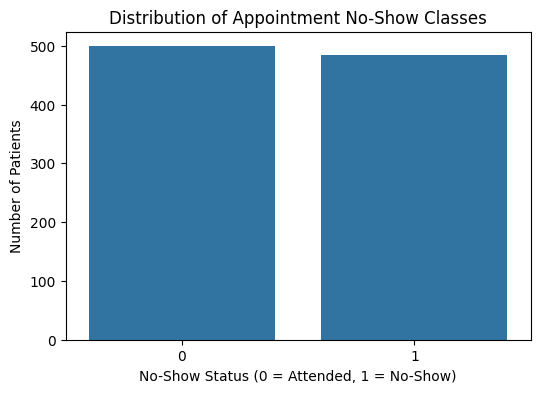

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="no_show"
)

plt.title("Distribution of Appointment No-Show Classes")
plt.xlabel("No-Show Status (0 = Attended, 1 = No-Show)")
plt.ylabel("Number of Patients")

plt.show()

#### check exact values

In [61]:
class_counts = df_clean["no_show"].value_counts()
class_percentages = df_clean["no_show"].value_counts(normalize=True) * 100

print(class_counts)
print(class_percentages)

no_show
0    499
1    485
Name: count, dtype: int64
no_show
0    50.711382
1    49.288618
Name: proportion, dtype: float64


### Class Distribution Insight

The target variable is almost perfectly balanced.

Approximately 50.71% of records belong to the attended/other class, while 49.29% belong to the no-show class.

Therefore, severe target-class imbalance is not present in the cleaned dataset.

## 3. Histogram - Age Distribution

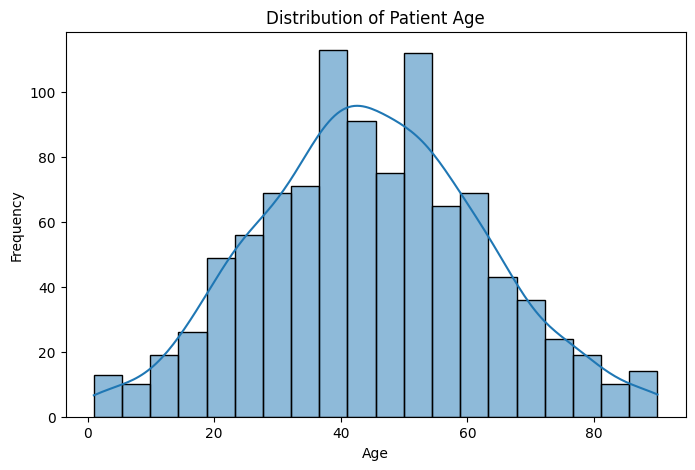

In [62]:
# visualization - Histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=20,
    kde=True
)

plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Age Distribution Insight

Patient ages range from 1 to 90 years, with a mean of approximately 44.77 years and a median of 45 years.

The distribution covers a broad age range, indicating that the dataset represents patients from different age groups rather than being concentrated within a narrow population.

## 4. Histogram - Waiting Days

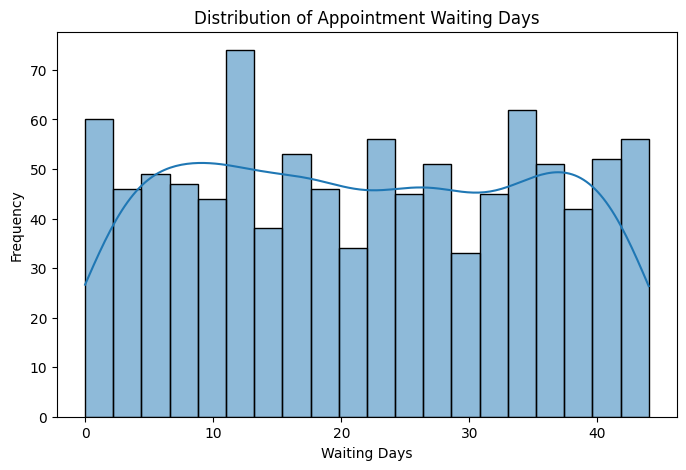

In [63]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="waiting_days",
    bins=20,
    kde=True
)

plt.title("Distribution of Appointment Waiting Days")
plt.xlabel("Waiting Days")
plt.ylabel("Frequency")

plt.show()

### Waiting Days Distribution

Appointment waiting time ranges from 0 to 44 days.

The mean waiting period is approximately 21.8 days, while the median is 22 days.

Because waiting time may influence the likelihood that a patient forgets or decides not to attend an appointment, this variable is especially relevant for no-show prediction.

## 5. Boxplot - Waiting Days vs No-Show

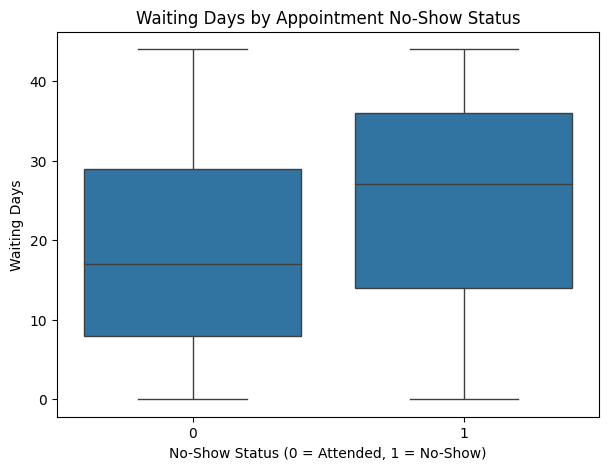

In [64]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="no_show",
    y="waiting_days"
)

plt.title("Waiting Days by Appointment No-Show Status")
plt.xlabel("No-Show Status (0 = Attended, 1 = No-Show)")
plt.ylabel("Waiting Days")

plt.show()

#### Now Calculate Means

In [65]:
df_clean.groupby("no_show")["waiting_days"].mean()

,waiting_days
no_show,
0,18.673347
1,25.006186


### Waiting Time Insight

Patients who eventually became no-shows had a noticeably longer average waiting period.

Patients in class 0 waited approximately 18.67 days on average, while patients in the no-show class waited approximately 25.01 days.

This indicates that longer appointment waiting periods may be associated with a higher probability of appointment non-attendance.

## 6. Boxplot - Previous No-Show Rate

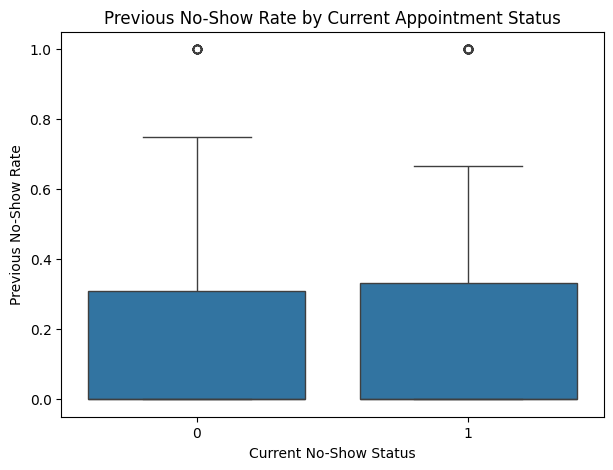

In [66]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="no_show",
    y="previous_no_show_rate"
)

plt.title("Previous No-Show Rate by Current Appointment Status")
plt.xlabel("Current No-Show Status")
plt.ylabel("Previous No-Show Rate")

plt.show()

#### Calculate Averages

In [67]:
df_clean.groupby("no_show")[
    "previous_no_show_rate"
].mean()

,previous_no_show_rate
no_show,
0,0.155163
1,0.213829


Patients who missed their current appointment had a higher average previous no-show rate than those who attended.

This suggests that historical appointment behaviour may contain useful predictive information.

## 7. Scatterplot

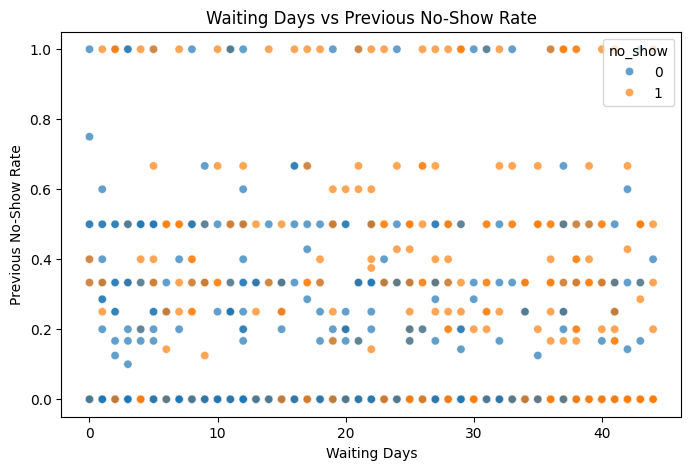

In [56]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="waiting_days",
    y="previous_no_show_rate",
    hue="no_show",
    alpha=0.7
)

plt.title("Waiting Days vs Previous No-Show Rate")
plt.xlabel("Waiting Days")
plt.ylabel("Previous No-Show Rate")

plt.show()

### Scatterplot Insight

The scatterplot compares appointment waiting time and previous no-show behaviour.

Although the two classes overlap considerably, no-show observations appear more frequently among patients with longer waiting periods and, in some cases, higher previous no-show rates.

This indicates that a combination of appointment timing and historical behaviour may provide more predictive information than either feature considered alone.

## 8. Correlation Analysis

#### Create the correlation matrix

In [57]:
correlation_features = [
    "age",
    "waiting_days",
    "previous_appointments",
    "missed_previous_appointments",
    "previous_admissions",
    "appointment_is_weekend",
    "previous_no_show_rate",
    "has_previous_no_show",
    "no_show"
]

correlation_matrix = df_clean[
    correlation_features
].corr()

correlation_matrix

,age,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,appointment_is_weekend,previous_no_show_rate,has_previous_no_show,no_show
age,1.000000,-0.034763,0.007692,-0.055773,-0.080721,-0.033482,-0.067189,-0.056973,-0.061924
waiting_days,-0.034763,1.000000,0.041249,-0.028815,-0.023307,0.004199,-0.020218,-0.028137,0.242918
previous_appointments,0.007692,0.041249,1.000000,0.401425,-0.014457,0.012565,0.013780,0.333495,-0.077484
missed_previous_appointments,-0.055773,-0.028815,0.401425,1.000000,0.017013,-0.040211,0.788487,0.875793,0.085630
previous_admissions,-0.080721,-0.023307,-0.014457,0.017013,1.000000,-0.004748,0.029587,0.004681,-0.013770
appointment_is_weekend,-0.033482,0.004199,0.012565,-0.040211,-0.004748,1.000000,-0.077201,-0.032591,0.015716
previous_no_show_rate,-0.067189,-0.020218,0.013780,0.788487,0.029587,-0.077201,1.000000,0.810824,0.108277
has_previous_no_show,-0.056973,-0.028137,0.333495,0.875793,0.004681,-0.032591,0.810824,1.000000,0.077990
no_show,-0.061924,0.242918,-0.077484,0.085630,-0.013770,0.015716,0.108277,0.077990,1.000000


#### Correlation with no_show


In [58]:
correlation_matrix["no_show"].sort_values(
    ascending=False
)

,no_show
no_show,1.000000
waiting_days,0.242918
previous_no_show_rate,0.108277
missed_previous_appointments,0.085630
has_previous_no_show,0.077990
appointment_is_weekend,0.015716
previous_admissions,-0.013770
age,-0.061924
previous_appointments,-0.077484


## 9. Correlation Heatmap

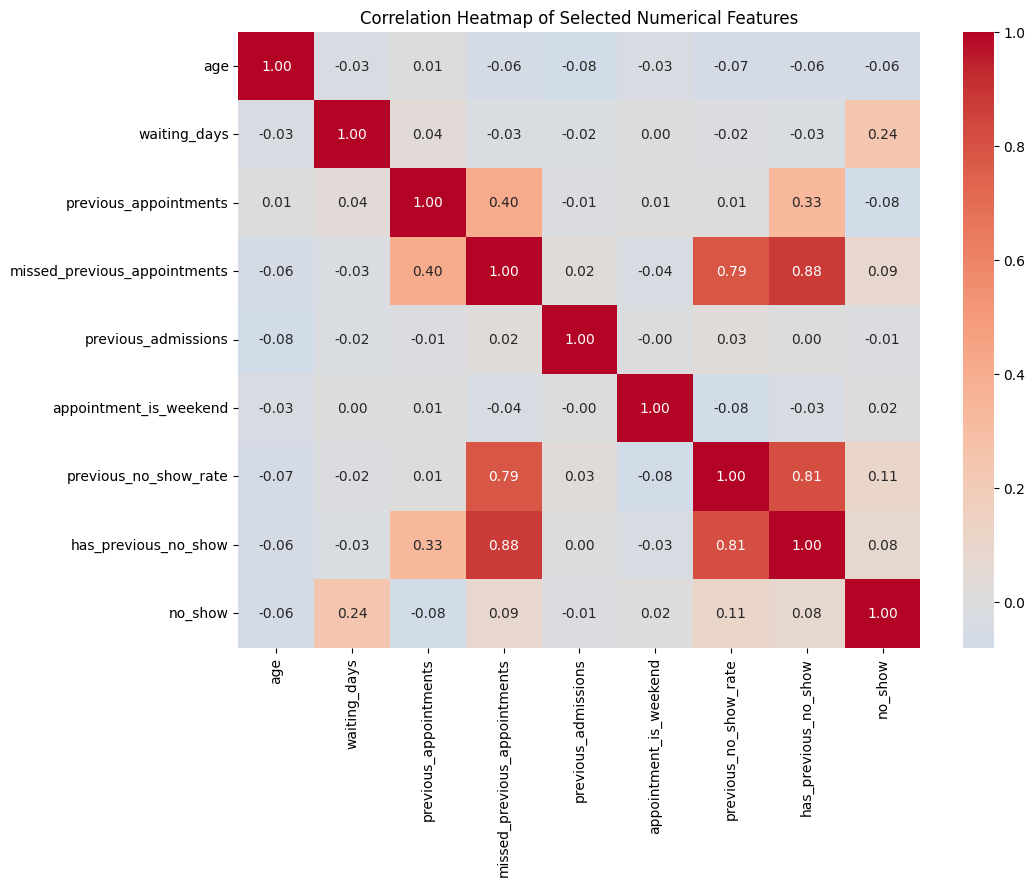

In [59]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Selected Numerical Features")

plt.show()

### Correlation Analysis

Among the selected numerical variables, waiting days showed the strongest positive correlation with appointment no-show status, with a correlation coefficient of approximately 0.243.

Previous no-show rate, missed previous appointments, and having a previous no-show also showed smaller positive relationships with the target.

The relationships are not extremely strong, which suggests that appointment no-show behaviour is unlikely to depend on one variable alone. Machine-learning models may therefore benefit from combining several features.

## 10. Pattern Discovery - Waiting Time Groups

#### Create Groups

In [68]:
df_clean["waiting_days_group"] = pd.cut(
    df_clean["waiting_days"],
    bins=[-1, 7, 14, 21, 30, 44],
    labels=[
        "0-7",
        "8-14",
        "15-21",
        "22-30",
        "31-44"
    ]
)

#### Calaculate no-Show rates

In [69]:
waiting_pattern = (
    df_clean
    .groupby("waiting_days_group", observed=True)["no_show"]
    .agg(["count", "mean"])
)

waiting_pattern["no_show_percentage"] = (
    waiting_pattern["mean"] * 100
)

waiting_pattern

,count,mean,no_show_percentage
waiting_days_group,,,
0-7,180,0.327778,32.777778
8-14,158,0.398734,39.873418
15-21,153,0.437908,43.790850
22-30,185,0.529730,52.972973
31-44,308,0.642857,64.285714


#### Plot It

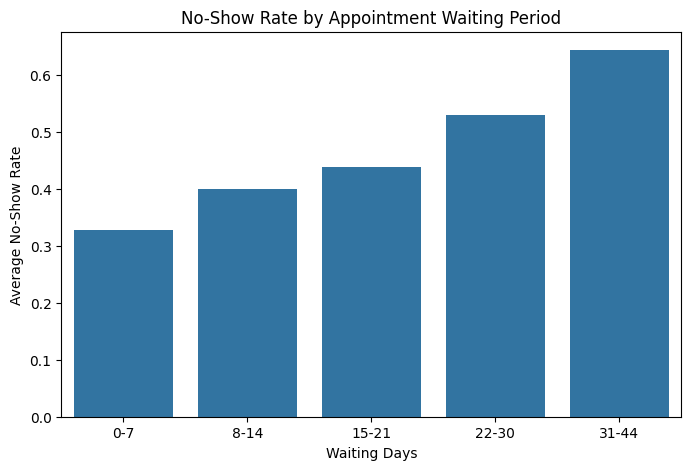

In [70]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="waiting_days_group",
    y="no_show",
    errorbar=None
)

plt.title("No-Show Rate by Appointment Waiting Period")
plt.xlabel("Waiting Days")
plt.ylabel("Average No-Show Rate")

plt.show()

### Waiting-Time Pattern

A clear increasing pattern was observed between appointment waiting time and non-attendance.

The no-show rate was approximately 32.8% among appointments scheduled within 0–7 days.

This increased progressively to approximately 64.3% among appointments with waiting periods between 31 and 44 days.

This suggests that appointment lead time may be an important predictor in the SmartCare dataset.

## 11. Pattern Discovery - Previous No-Show History

In [71]:
previous_history_pattern = (
    df_clean
    .groupby("has_previous_no_show")["no_show"]
    .agg(["count", "mean"])
)

previous_history_pattern["percentage"] = (
    previous_history_pattern["mean"] * 100
)

previous_history_pattern

,count,mean,percentage
has_previous_no_show,,,
0,578,0.460208,46.020761
1,406,0.539409,53.940887


#### Plot

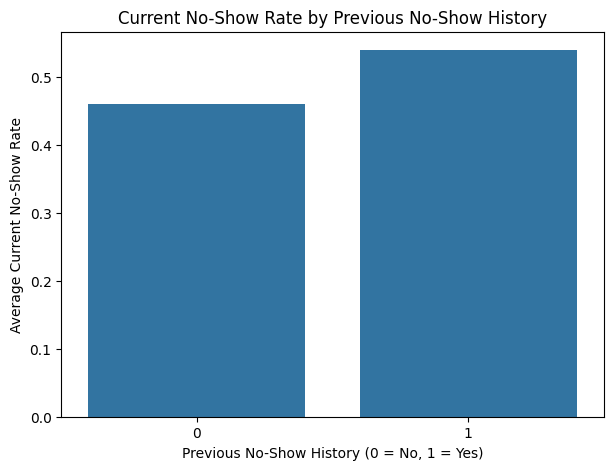

In [72]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="has_previous_no_show",
    y="no_show",
    errorbar=None
)

plt.title("Current No-Show Rate by Previous No-Show History")
plt.xlabel("Previous No-Show History (0 = No, 1 = Yes)")
plt.ylabel("Average Current No-Show Rate")

plt.show()

Patients who had previously missed at least one appointment had a current no-show rate of approximately 53.9%.

Patients without previous missed appointments had a lower rate of approximately 46.0%.

Therefore, previous non-attendance history appears to provide useful predictive information.

## 12. Department Pattern

In [73]:
department_no_show = (
    df_clean
    .groupby("department")["no_show"]
    .mean()
    .sort_values(ascending=False)
)

department_no_show

,no_show
department,
Neurology,0.547945
Cardiology,0.532051
General Medicine,0.487342
Pediatrics,0.485294
Radiology,0.485075
Laboratory Services,0.482456
Orthopedics,0.421429


#### Plot

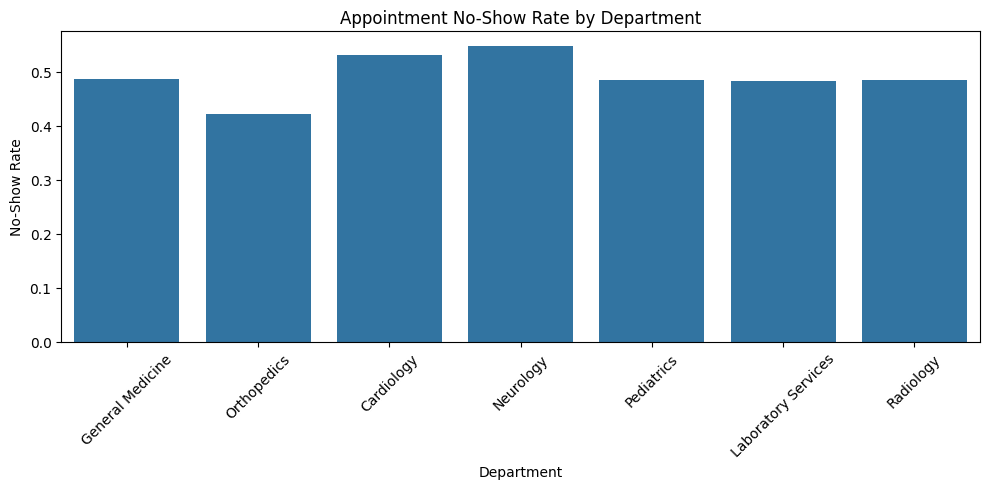

In [74]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_clean,
    x="department",
    y="no_show",
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Appointment No-Show Rate by Department")
plt.xlabel("Department")
plt.ylabel("No-Show Rate")

plt.tight_layout()
plt.show()

No-show proportions differ across hospital departments.

Neurology and Cardiology recorded relatively higher no-show proportions, while Orthopedics showed a lower rate in this dataset.

However, these differences should not automatically be interpreted as causal because other patient and scheduling characteristics may contribute to the observed patterns.

## 13. Day-of - Week Pattern

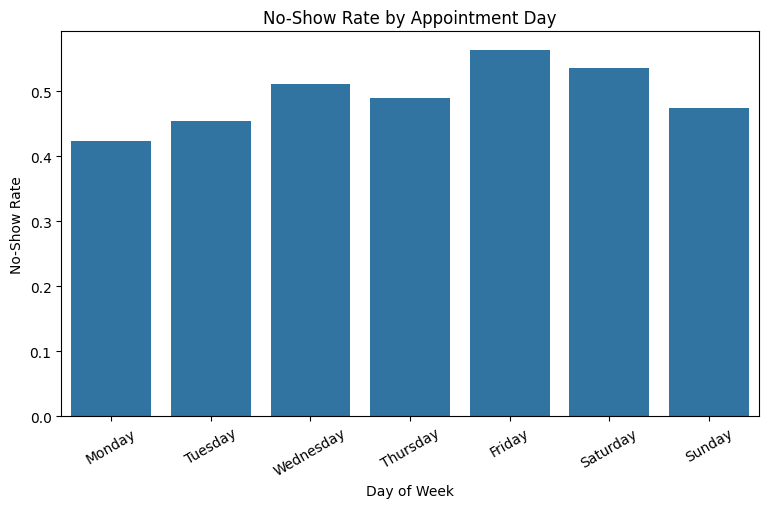

In [75]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_clean,
    x="appointment_day_of_week",
    y="no_show",
    order=day_order,
    errorbar=None
)

plt.title("No-Show Rate by Appointment Day")
plt.xlabel("Day of Week")
plt.ylabel("No-Show Rate")

plt.xticks(rotation=30)

plt.show()

# Task 05 - Machine Learning Model Development

Three classification algorithms are developed and compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models are trained to predict the binary target variable `no_show`

## 1. Import the required libraries

In [76]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

import pandas as pd

## 2. pipelines use For

### Model Training Strategy

A Scikit-Learn Pipeline is used to combine preprocessing and model
training.

This ensures that preprocessing transformations are learned only
from the training data during cross-validation, helping to prevent
data leakage.

Five-fold stratified cross-validation is used to compare model
performance while preserving the class distribution in each fold.

## 3. Create the three models

In [77]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

random_forest_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

#### Now create the pipelines

In [78]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", decision_tree_model)
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

## 4. Define cross-validation

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 5. Define evaluation measures for model development

In [79]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

## 6. Baseline Logistic Regression

In [82]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression")

print(
    "Mean Accuracy:",
    logistic_cv["test_accuracy"].mean()
)

print(
    "Mean Precision:",
    logistic_cv["test_precision"].mean()
)

print(
    "Mean Recall:",
    logistic_cv["test_recall"].mean()
)

print(
    "Mean F1:",
    logistic_cv["test_f1"].mean()
)

print(
    "Mean ROC-AUC:",
    logistic_cv["test_roc_auc"].mean()
)

Logistic Regression
Mean Accuracy: 0.5667661049746029
Mean Precision: 0.5613307934721661
Mean Recall: 0.5723609723609723
Mean F1: 0.5659940540888397
Mean ROC-AUC: 0.5916622934027999


## 7. Baseline Decision Tree

In [83]:
decision_tree_cv = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Decision Tree")

print(
    "Mean Accuracy:",
    decision_tree_cv["test_accuracy"].mean()
)

print(
    "Mean Precision:",
    decision_tree_cv["test_precision"].mean()
)

print(
    "Mean Recall:",
    decision_tree_cv["test_recall"].mean()
)

print(
    "Mean F1:",
    decision_tree_cv["test_f1"].mean()
)

print(
    "Mean ROC-AUC:",
    decision_tree_cv["test_roc_auc"].mean()
)

Decision Tree
Mean Accuracy: 0.5108199629121988
Mean Precision: 0.5038688219411112
Mean Recall: 0.5284382284382284
Mean F1: 0.5152625142093833
Mean ROC-AUC: 0.511070380041899


## 8. Baseline Random Forest

In [84]:
random_forest_cv = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Random Forest")

print(
    "Mean Accuracy:",
    random_forest_cv["test_accuracy"].mean()
)

print(
    "Mean Precision:",
    random_forest_cv["test_precision"].mean()
)

print(
    "Mean Recall:",
    random_forest_cv["test_recall"].mean()
)

print(
    "Mean F1:",
    random_forest_cv["test_f1"].mean()
)

print(
    "Mean ROC-AUC:",
    random_forest_cv["test_roc_auc"].mean()
)

Random Forest
Mean Accuracy: 0.5641538337498992
Mean Precision: 0.5611147381369309
Mean Recall: 0.5361638361638362
Mean F1: 0.5482071954118484
Mean ROC-AUC: 0.5795300532800531


## 9. Create baseline comparison table

In [85]:
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_cv["test_accuracy"].mean(),
        decision_tree_cv["test_accuracy"].mean(),
        random_forest_cv["test_accuracy"].mean()
    ],

    "Precision": [
        logistic_cv["test_precision"].mean(),
        decision_tree_cv["test_precision"].mean(),
        random_forest_cv["test_precision"].mean()
    ],

    "Recall": [
        logistic_cv["test_recall"].mean(),
        decision_tree_cv["test_recall"].mean(),
        random_forest_cv["test_recall"].mean()
    ],

    "F1 Score": [
        logistic_cv["test_f1"].mean(),
        decision_tree_cv["test_f1"].mean(),
        random_forest_cv["test_f1"].mean()
    ],

    "ROC-AUC": [
        logistic_cv["test_roc_auc"].mean(),
        decision_tree_cv["test_roc_auc"].mean(),
        random_forest_cv["test_roc_auc"].mean()
    ]
})

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5668,0.5613,0.5724,0.5660,0.5917
1,Decision Tree,0.5108,0.5039,0.5284,0.5153,0.5111
2,Random Forest,0.5642,0.5611,0.5362,0.5482,0.5795


## 10. Hyperparameter Tuning

### We use
GridSearchCV

### We'll optimize
F1 Score

### F1 use for
becaus over positive class is  No-Show = 1

### F1 Considers both
Precision + Recall


## 11. Tune Logistic Regression

In [86]:
logistic_param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "model__solver": [
        "liblinear",
        "lbfgs"
    ]
}

#### Grid Search

In [87]:
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

logistic_grid.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:",
    logistic_grid.best_params_
)

print(
    "Best CV F1:",
    logistic_grid.best_score_
)

Best Parameters: {'model__C': 0.01, 'model__solver': 'liblinear'}
Best CV F1: 0.5730120582671792


## 12. Tune Decision Tree

In [88]:
decision_tree_param_grid = {
    "model__criterion": [
        "gini",
        "entropy"
    ],

    "model__max_depth": [
        3,
        5,
        7,
        10,
        None
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [89]:
decision_tree_grid = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=decision_tree_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

decision_tree_grid.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:",
    decision_tree_grid.best_params_
)

print(
    "Best CV F1:",
    decision_tree_grid.best_score_
)

Best Parameters: {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV F1: 0.5629237453668855


## 13. Tune Random Forest

In [90]:
random_forest_param_grid = {
    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        5,
        10,
        None
    ],

    "model__min_samples_split": [
        2,
        5
    ],

    "model__min_samples_leaf": [
        1,
        2
    ]
}

In [91]:
random_forest_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

random_forest_grid.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:",
    random_forest_grid.best_params_
)

print(
    "Best CV F1:",
    random_forest_grid.best_score_
)

Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV F1: 0.5646939872258343


## 14. Compare the tuned models

In [92]:
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Best CV F1": [
        logistic_grid.best_score_,
        decision_tree_grid.best_score_,
        random_forest_grid.best_score_
    ]
})

tuned_results = tuned_results.sort_values(
    by="Best CV F1",
    ascending=False
)

tuned_results.round(4)

,Model,Best CV F1
0,Logistic Regression,0.5730
2,Random Forest,0.5647
1,Decision Tree,0.5629


## 15. Store the best tuned models

#### Save them in to Variable

In [93]:
best_logistic_model = (
    logistic_grid.best_estimator_
)

best_decision_tree_model = (
    decision_tree_grid.best_estimator_
)

best_random_forest_model = (
    random_forest_grid.best_estimator_
)